In [69]:
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
import IPython.display as ipd
import tensorflow.keras.layers as layers
from sklearn import metrics
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import librosa.display
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import csv
from pathlib import Path
from PIL import Image
import os
import matplotlib.pyplot as plt
import librosa
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [70]:
# Let's read a sample audio using librosa
import librosa
audio_file_path = "/home/wdxm/code/luck_fox/luckfox_pico_rkmpi_example/examples/mfcc/datasets/cats_dogs/train/dog/dog_barking_2.wav"
librosa_audio_data, librosa_sample_rate = librosa.load(audio_file_path)

In [71]:
print(librosa_audio_data)
print(librosa_sample_rate)

[-0.00324605 -0.0070152  -0.00960182 ...  0.01316906  0.01514705
  0.00953149]
22050


In [72]:
mfccs = librosa.feature.mfcc(y=librosa_audio_data, sr=librosa_sample_rate, n_mfcc=40)
print(mfccs.shape)

(40, 513)


In [73]:
a=[]
a.append(mfccs)

In [74]:
## Data preprocessing

In [75]:
# 频谱图增强
"""def get_spectrogram(wav):
    D = librosa.stft(wav, n_fft=480, hop_length=160,
                     win_length=480, window='hamming')
    spect, phase = librosa.magphase(D)
    return spect"""

"def get_spectrogram(wav):\n    D = librosa.stft(wav, n_fft=480, hop_length=160,\n                     win_length=480, window='hamming')\n    spect, phase = librosa.magphase(D)\n\xa0\xa0\xa0\xa0return\xa0spect"

In [76]:
# 音频增强 - 时域转换
"""start_ = int(np.random.uniform(-4800,4800))
print('time shift: ',start_)
if start_ >= 0:
    wav_time_shift = np.r_[wav[start_:], np.random.uniform(-0.001,0.001, start_)]
else:
    wav_time_shift = np.r_[np.random.uniform(-0.001,0.001, -start_), wav[:start_]]
ipd.Audio(wav_time_shift, rate=sr)"""

"start_ = int(np.random.uniform(-4800,4800))\nprint('time shift: ',start_)\nif start_ >= 0:\n    wav_time_shift = np.r_[wav[start_:], np.random.uniform(-0.001,0.001, start_)]\nelse:\n    wav_time_shift = np.r_[np.random.uniform(-0.001,0.001, -start_), wav[:start_]]\nipd.Audio(wav_time_shift,\xa0rate=sr)"

In [77]:
# 速度调节
"""
speed_rate = np.random.uniform(0.7,1.3)
wav_speed_tune = cv2.resize(wav, (1, int(len(wav) * speed_rate))).squeeze()
print('speed rate: %.3f' % speed_rate, '(lower is faster)')
if len(wav_speed_tune) < 16000:
    pad_len = 16000 - len(wav_speed_tune)
    wav_speed_tune = np.r_[np.random.uniform(-0.001,0.001,int(pad_len/2)),
                           wav_speed_tune,
                           np.random.uniform(-0.001,0.001,int(np.ceil(pad_len/2)))]
else: 
    cut_len = len(wav_speed_tune) - 16000
    wav_speed_tune = wav_speed_tune[int(cut_len/2):int(cut_len/2)+16000]
print('wav length: ', wav_speed_tune.shape[0])
ipd.Audio(wav_speed_tune, rate=sr)"""

"\nspeed_rate = np.random.uniform(0.7,1.3)\nwav_speed_tune = cv2.resize(wav, (1, int(len(wav) * speed_rate))).squeeze()\nprint('speed rate: %.3f' % speed_rate, '(lower is faster)')\nif len(wav_speed_tune) < 16000:\n    pad_len = 16000 - len(wav_speed_tune)\n    wav_speed_tune = np.r_[np.random.uniform(-0.001,0.001,int(pad_len/2)),\n                           wav_speed_tune,\n                           np.random.uniform(-0.001,0.001,int(np.ceil(pad_len/2)))]\nelse: \n    cut_len = len(wav_speed_tune) - 16000\n    wav_speed_tune = wav_speed_tune[int(cut_len/2):int(cut_len/2)+16000]\nprint('wav length: ', wav_speed_tune.shape[0])\nipd.Audio(wav_speed_tune,\xa0rate=sr)"

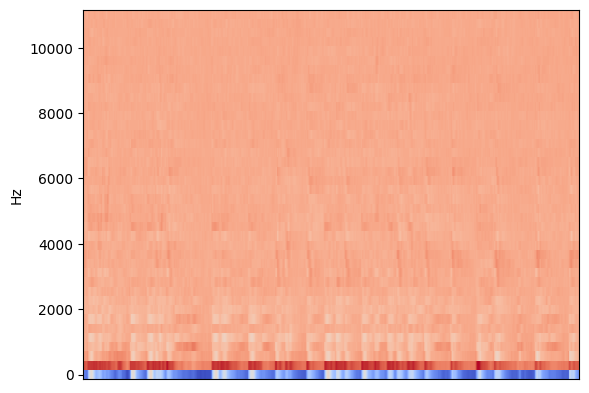

In [78]:
librosa.display.specshow(mfccs, y_axis='linear')

In [79]:
import numpy as np
dataset = []
cla = []
genres = {'cat': 0, 'dog': 1}

for genre, genre_number in genres.items():
    for filename in os.listdir(f'/home/wdxm/code/luck_fox/luckfox_pico_rkmpi_example/examples/mfcc/datasets/cats_dogs/train/{genre}'):
        songname = f'/home/wdxm/code/luck_fox/luckfox_pico_rkmpi_example/examples/mfcc/datasets/cats_dogs/train/{genre}/{filename}'
        # for index in range(14):
        audio, sr = librosa.load(songname)
        mfcc_fea = np.mean(librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40).T,axis=0)
        fea_class=genre
        dataset.append(mfcc_fea)
        cla.append(fea_class)

In [80]:
d = {'Features':dataset,'class':cla}
print(d)

{'Features': [array([-2.86793732e+02,  1.05949715e+02, -1.77104294e+00,  2.94464054e+01,
       -1.03185921e+01,  2.64130669e+01, -5.05594635e+00,  9.45723629e+00,
       -4.97987127e+00, -5.47496796e-01,  3.00958419e+00,  1.65792251e+00,
        7.14568806e+00, -6.10039425e+00,  8.83379102e-01, -1.26770716e+01,
        5.07365525e-01, -3.01151943e+00, -1.42183447e+00, -2.76438403e+00,
       -2.77559805e+00,  3.90108657e+00, -1.36924759e-02,  4.45249319e+00,
       -1.10328472e+00,  4.32464504e+00, -1.57983863e+00,  9.58027184e-01,
        2.06414390e+00,  1.47217214e+00,  5.22498369e-01,  2.32932940e-01,
        4.73804092e+00, -1.33336365e+00,  2.47229385e+00, -7.24388719e-01,
       -8.01608205e-01, -3.46523076e-01,  1.90235364e+00, -4.26104873e-01],
      dtype=float32), array([-3.7665268e+02,  1.1613464e+02, -4.2612694e+01,  3.4147678e+01,
       -1.7689964e+01,  2.7609070e+01, -1.2929417e+01,  1.7185751e+01,
       -1.2851142e+00,  8.8451471e+00,  2.1892614e+00,  2.4408160e-02,


In [81]:
import pandas as pd
extracted_features_df=pd.DataFrame(d)
extracted_features_df.head()

,Features,class
0,"[-286.79373, 105.949715, -1.771043, 29.446405,...",cat
1,"[-376.65268, 116.13464, -42.612694, 34.14768, ...",cat
2,"[-306.19803, 105.59843, -13.567793, 39.501755,...",cat
3,"[-284.35168, 57.33731, -48.727867, 10.751871, ...",cat
4,"[-391.7666, 88.39284, 14.679693, 34.564114, 8....",cat


In [82]:
### Split the dataset into independent and dependent dataset
X=np.array(extracted_features_df['Features'].tolist())
# extracted_features_df['Features'].tolist()
y=np.array(extracted_features_df['class'].tolist())

In [83]:
X.shape

(210, 40)

In [84]:
y.shape

(210,)

In [ ]:
### Label Encoding
### y=np.array(pd.get_dummies(y))
### Label Encoder
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
labelencoder=LabelEncoder()
y=to_categorical(labelencoder.fit_transform(y))
print(y)

[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 

In [86]:
### Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [87]:
X_train.shape

(168, 40)

In [88]:
X_test.shape

(42, 40)

In [89]:
y_train.shape

(168, 2)

In [90]:
y_test.shape

(42, 2)

In [91]:
X_train=np.reshape(X_train,(X_train.shape[0],10,4,1))
X_test=np.reshape(X_test,(X_test.shape[0],10,4,1))

In [92]:
INPUTSHAPE = (10,4,1)

In [93]:
## Model Architecture

In [94]:
model = Sequential([
    layers.Conv2D(32, (3, 3), activation='relu',
                  padding='valid', input_shape=INPUTSHAPE),
    layers.MaxPooling2D(2, padding='same'),
    # layers.Conv2D(128, (3,3), activation='relu',padding='valid'),
    # layers.MaxPooling2D(2, padding='same'),
    # layers.Dropout(0.3),
    # layers.Conv2D(128, (3,3), activation='relu',padding='valid'),
    # layers.MaxPooling2D(2, padding='same'),
    # layers.Dropout(0.3),
    # layers.GlobalAveragePooling2D(),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(2, activation='softmax')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 8, 2, 32)          320       
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 4, 1, 32)          0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 512)               66048     
                                                                 
 dense_3 (Dense)             (None, 2)                 1026      
                                                                 
Total params: 67394 (263.26 KB)
Trainable params: 67394 (263.26 KB)
Non-trainable params: 0 (0.00 Byte)
________________

In [95]:
batch_size = 8
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', min_delta=0, patience=8, verbose=0, mode='auto',
    baseline=None, restore_best_weights=False)
#checkpointer = ModelCheckpoint(filepath='saved_models/audio_classification.hdf5', 
                             # verbose=1, save_best_only=True)
# pip install -U nvidia-cudnn-cu12
history = model.fit(X_train,y_train ,validation_data=(X_test,y_test),
            epochs=40,
            callbacks = [callback],batch_size=batch_size)

Epoch 1/40
21/21 [==============================] - 0s 7ms/step - loss: 0.9823 - acc: 0.7560 - val_loss: 0.3582 - val_acc: 0.9286
Epoch 2/40
21/21 [==============================] - 0s 3ms/step - loss: 0.4683 - acc: 0.8452 - val_loss: 0.4248 - val_acc: 0.8571
Epoch 3/40
21/21 [==============================] - 0s 3ms/step - loss: 0.3378 - acc: 0.8571 - val_loss: 0.3825 - val_acc: 0.8095
Epoch 4/40
21/21 [==============================] - 0s 3ms/step - loss: 0.3242 - acc: 0.8810 - val_loss: 0.2045 - val_acc: 0.9524
Epoch 5/40
21/21 [==============================] - 0s 3ms/step - loss: 0.3535 - acc: 0.8810 - val_loss: 0.2678 - val_acc: 0.8571
Epoch 6/40
21/21 [==============================] - 0s 3ms/step - loss: 0.2508 - acc: 0.9167 - val_loss: 0.2504 - val_acc: 0.9048
Epoch 7/40
21/21 [==============================] - 0s 3ms/step - loss: 0.1794 - acc: 0.9107 - val_loss: 0.2569 - val_acc: 0.8810
Epoch 8/40
21/21 [==============================] - 0s 3ms/step - loss: 0.1596 - acc: 0.94

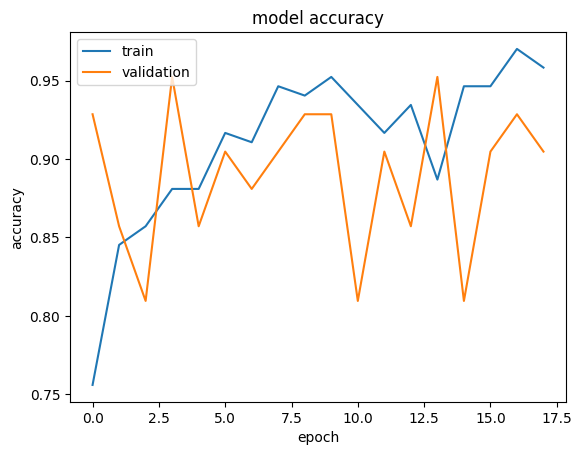

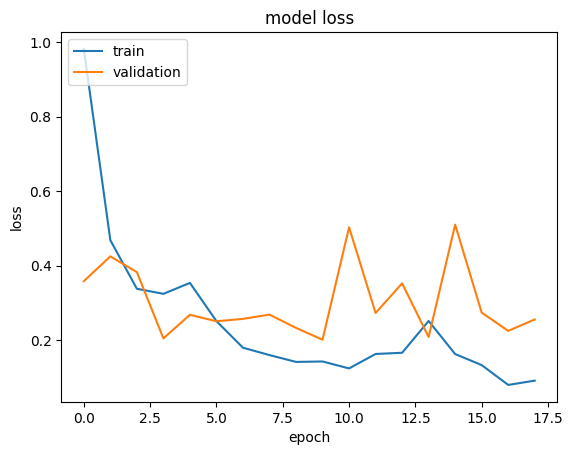

In [96]:
import matplotlib.pyplot as plt
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()


plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [97]:
%matplotlib inline
from sklearn.metrics import confusion_matrix
import itertools
import matplotlib.pyplot as plt

In [98]:
y_pred=model.predict(X_test)

2/2 [==============================] - 0s 3ms/step


In [99]:
round_off=np.round_(y_pred)

Confusion Matrix
[[23  2]
 [ 2 15]]


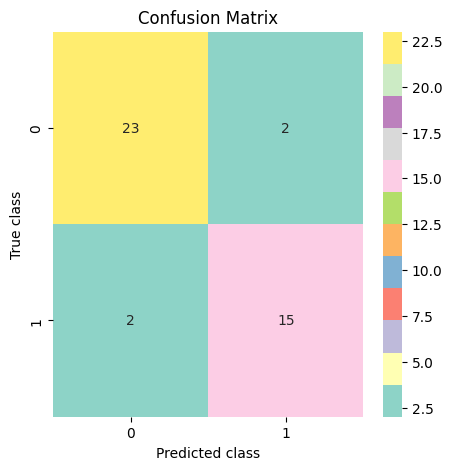

In [100]:
import seaborn as sns
# from sklearn.metrics import plot_confusion_matrix
cm=confusion_matrix(y_test.argmax(axis=1),round_off.argmax(axis=1))
print("Confusion Matrix")
print(cm)

plt.figure(figsize=(5,5))
sns.heatmap(cm,annot=True,fmt="d",cmap='Set3')
plt.title("Confusion Matrix")
plt.ylabel("True class")
plt.xlabel("Predicted class")
plt.show()

In [110]:
import librosa
mydict = {'cat': 0, 'dog': 1}
audio_file_path = "/home/wdxm/code/luck_fox/luckfox_pico_rkmpi_example/examples/mfcc/datasets/cats_dogs/test/cat/cat_14.wav"
# audio_file_path = "/home/wdxm/code/luck_fox/luckfox_pico_rkmpi_example/examples/mfcc/datasets/cats_dogs/test/dog/dog_barking_24.wav"
librosa_audio_data, librosa_sample_rate = librosa.load(audio_file_path)
mfccs = np.mean(librosa.feature.mfcc(y=librosa_audio_data,
                sr=librosa_sample_rate, n_mfcc=40).T, axis=0)
x = []
x.append(mfccs)
x = np.array(x)
x = np.reshape(x, (x.shape[0], 10, 4, 1))
y_pre = model.predict(x)
y_pre = np.round_(y_pre)
print(y_pre)
a, b = np.where(y_pre == 1)
print(a, b)
for gerne, classs in mydict.items():
    if classs == b[0]:
        print(gerne)

1/1 [==============================] - 0s 25ms/step
[[0. 1.]]
[0] [1]
dog
